In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 

Lx = 50
Ly = 3
K = 2 
J = 1 
W = 4 

N = Lx * Ly 

print ("Total number of sites =", N)

# Function to create one random T matrix 

def create_random_T(Ly, K):

    while True:

        Tx = np.zeros((Ly, Ly), dtype=int)

        for j in range(Ly):

            rows = np.random.choice(Ly, K, replace=False)

            for i in rows:
                Tx[i, j] = 1

        row_sum = np.sum(Tx, axis=1)
        col_sum = np.sum(Tx, axis=0)

        if np.all(row_sum == K) and np.all(col_sum == K):
            return Tx

# Create T matrices for all neighboring layers

np.random.seed(0)

T = []

for x in range(Lx - 1):

    Tx = create_random_T(Ly, K)
    T.append(Tx)


    print(f"\nConnection matrix T({x+1}, {x+2}):")
    print(Tx)

    print("Row sums:    ", Tx.sum(axis=1))
    print("Column sums: ", Tx.sum(axis=0))


Total number of sites = 150

Connection matrix T(1, 2):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(2, 3):
[[1 1 0]
 [0 1 1]
 [1 0 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(3, 4):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(4, 5):
[[1 0 1]
 [1 1 0]
 [0 1 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(5, 6):
[[1 0 1]
 [0 1 1]
 [1 1 0]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(6, 7):
[[0 1 1]
 [1 1 0]
 [1 0 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(7, 8):
[[1 1 0]
 [1 0 1]
 [0 1 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(8, 9):
[[0 1 1]
 [1 1 0]
 [1 0 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(9, 10):
[[1 1 0]
 [0 1 1]
 [1 0 1]]
Row sums:     [2 2 2]
Column sums:  [2 2 2]

Connection matrix T(10, 11):
[[1 0 1]
 [1 1 0]
 [0 1 1]]
Row sums:    

In [16]:

# Create random onsite potentials

np.random.seed(0)
epsilon = np.random.uniform(-W/2, W/2, size=(Lx, Ly))

print("\nOnsite potential epsilon:")
print(np.round(epsilon, 2))


Onsite potential epsilon:
[[ 0.2   0.86  0.41]
 [ 0.18 -0.31  0.58]
 [-0.25  1.57  1.85]
 [-0.47  1.17  0.12]
 [ 0.27  1.7  -1.72]
 [-1.65 -1.92  1.33]
 [ 1.11  1.48  1.91]
 [ 1.2  -0.15  1.12]
 [-1.53  0.56 -1.43]
 [ 1.78  0.09 -0.34]
 [-0.94  1.1  -0.18]
 [ 0.27 -1.92  0.47]
 [ 0.45  0.47  1.77]
 [ 0.73 -0.56 -0.25]
 [ 0.79 -1.76  0.67]
 [ 0.68 -1.16 -1.48]
 [-0.74 -0.55  0.28]
 [-0.25  1.95 -1.59]
 [-1.16 -1.35  0.61]
 [-0.99 -0.13 -1.02]
 [-1.36 -1.56  0.63]
 [-1.45 -1.21 -0.53]
 [ 1.28 -1.61  1.35]
 [-1.62  1.91 -0.13]
 [ 1.91  0.42  0.96]
 [-1.84 -0.87 -1.52]
 [-0.82 -1.53 -0.73]
 [-0.34 -1.74  0.77]
 [ 0.27 -0.94  0.09]
 [-1.62  0.3   1.72]
 [-0.73  0.67 -1.47]
 [ 0.87 -0.84 -1.27]
 [ 0.35 -1.92  1.32]
 [-1.98  0.71 -0.92]
 [ 0.94  1.85 -1.  ]
 [ 0.3   0.37  0.29]
 [-1.11  1.81 -0.21]
 [ 1.39  0.8  -0.81]
 [ 1.26 -0.41  1.52]
 [ 0.33  1.53  0.77]
 [ 0.9   0.01  1.82]
 [ 0.58 -0.3   0.43]
 [-1.92 -0.79  0.64]
 [-0.84  0.47 -0.28]
 [-1.46 -0.81  0.28]
 [ 0.36  0.3   0.61]
 [ 0.61

# Create the Hamiltonian

In [17]:
H = np.zeros((N, N))

# Put onsite potentails on the diagonal 

for x in range(Lx):
    for y in range(Ly):

        site = x * Ly + y 

        H[site, site] = epsilon[x, y]    # Take the onsite potential belonging to the physical site (x,y), and put it on the corresponding diagonal element of the Hamiltonian.
        


In [18]:
# Put the hopping terms between neighboring layers 

for x in range(Lx - 1):

    Tx = T[x]

    for i in range(Ly):
        for j in range(Ly):

            if Tx[i, j] == 1:

                site1 = x * Ly + j     # Site j in layer x

                site2 = (x + 1) * Ly + i    # Site i in layer x+1 

                H[site1, site2] = J 
                H[site2, site1] = J 



In [19]:
print ("\nHamiltonian H:")
print(H)



Hamiltonian H:
[[0.19525402 0.         0.         ... 0.         0.         0.        ]
 [0.         0.86075747 0.         ... 0.         0.         0.        ]
 [0.         0.         0.4110535  ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.67793045 0.         0.        ]
 [0.         0.         0.         ... 0.         0.8569652  0.        ]
 [0.         0.         0.         ... 0.         0.         1.99538803]]


In [20]:
print("\nIs H Hermitian?")
print(np.allclose(H, H.T))


Is H Hermitian?
True


# Plot the Hamiltonian 

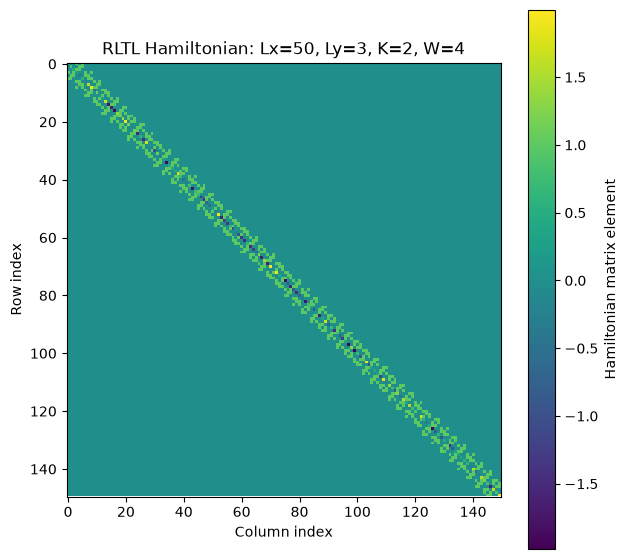

In [21]:
plt.figure(figsize=(7, 7))

plt.imshow(H, interpolation="None")

plt.colorbar(label="Hamiltonian matrix element")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(f"RLTL Hamiltonian: Lx={Lx}, Ly={Ly}, K={K}, W={W}")
plt.show()


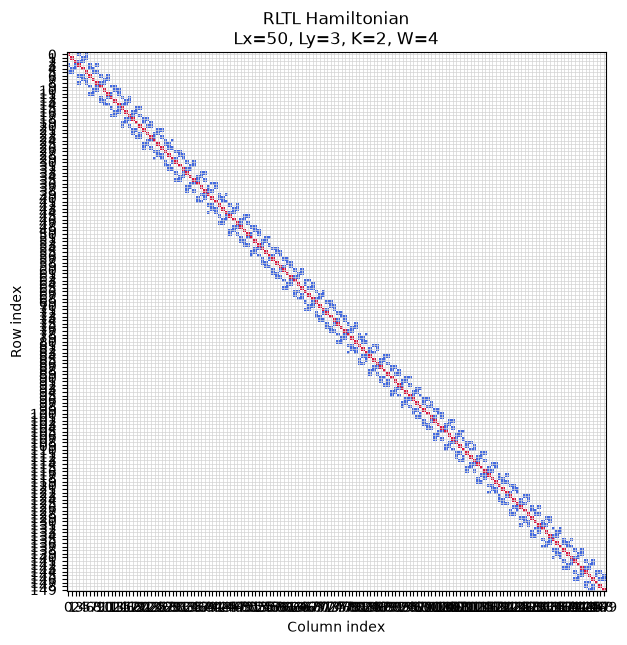

In [22]:
from matplotlib.colors import ListedColormap

plot_matrix = np.zeros((N, N), dtype=int)

for i in range(N):
    for j in range(N):

        if i != j and H[i, j] == J:

            plot_matrix[i, j] = 1 


for i in range(N):

    if H[i, i] != 0:

        plot_matrix[i, i] = 2

cmap = ListedColormap(["white", "royalblue", "crimson"])

plt.figure (figsize=(7, 7))

plt.imshow(plot_matrix, cmap=cmap, interpolation="none")

plt.xlabel("Column index")
plt.ylabel("Row index")

plt.title(
    f"RLTL Hamiltonian\n"
    f"Lx={Lx}, Ly={Ly}, K={K}, W={W}"
)

plt.xticks(np.arange(N))
plt.yticks(np.arange(N))

plt.grid(
    True,
    color="lightgray",
    linewidth=0.5
)

plt.show()


# Diagonalize the Hamiltonian 

In [23]:
eigenvalues, eigenvectors = np.linalg.eigh(H)

print("\nEigenvalues:")
print(np.round(eigenvalues, 2))

print("\nEigenvectors:")
print(np.round(eigenvectors, 2))

print("\nEigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues:
[-4.63 -4.56 -4.37 -4.28 -4.21 -4.15 -3.93 -3.79 -3.63 -3.51 -3.39 -3.27
 -3.09 -2.99 -2.98 -2.94 -2.88 -2.87 -2.8  -2.7  -2.67 -2.43 -2.41 -2.39
 -2.35 -2.32 -2.3  -2.26 -2.23 -2.22 -2.14 -2.11 -2.05 -2.03 -1.86 -1.8
 -1.75 -1.69 -1.67 -1.6  -1.59 -1.55 -1.46 -1.44 -1.41 -1.32 -1.29 -1.29
 -1.23 -1.18 -1.13 -1.08 -1.02 -0.98 -0.95 -0.92 -0.87 -0.74 -0.66 -0.64
 -0.61 -0.56 -0.52 -0.45 -0.43 -0.38 -0.34 -0.33 -0.3  -0.22 -0.19 -0.13
 -0.12 -0.    0.03  0.13  0.15  0.26  0.28  0.33  0.35  0.39  0.45  0.49
  0.54  0.56  0.61  0.62  0.71  0.71  0.8   0.84  0.87  0.92  0.98  1.05
  1.1   1.16  1.27  1.29  1.32  1.42  1.43  1.47  1.49  1.52  1.6   1.62
  1.64  1.7   1.73  1.77  1.78  1.84  1.92  1.97  1.99  2.02  2.06  2.1
  2.14  2.17  2.27  2.34  2.41  2.43  2.45  2.59  2.65  2.68  2.7   2.77
  2.79  2.86  2.89  2.99  3.07  3.13  3.4   3.47  3.6   3.71  3.86  4.09
  4.14  4.17  4.26  4.29  4.56  4.62]

Eigenvectors:
[[ 0.   -0.    0.   ...  0.   -0.06  0.  ]
 [ 0.   -0.    0

# Check that the diagonalization is correct 

In [33]:
n = [0, 1, 2, 3, 4]

for n in range(len(eigenvalues)):
    # print(f"\nEigenvalue {n}: {eigenvalues[n]}")
    # print(f"Eigenvector {n}: {np.round(eigenvectors[:, n], 2)}")

    left = H @ eigenvectors[:, n]
    right = eigenvalues[n] * eigenvectors[:, n]

    print(np.allclose(left, right))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


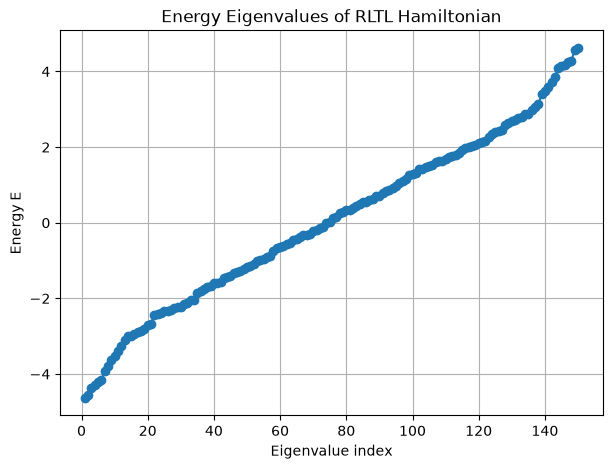

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(range(1, N + 1), eigenvalues, 'o-')

plt.xlabel("Eigenvalue index")
plt.ylabel("Energy E")
plt.title("Energy Eigenvalues of RLTL Hamiltonian")

plt.grid()
plt.show()

# Level-Spacing Ratio

In [27]:
# Number of states to consider 
num_states = N//32 
print ("Number of central states =", num_states)

if num_states < 3:
    print("N is too small to claculate the level-spacing ratio")

else:
    center = N // 2

    start = center - num_states // 2 
    end = center + num_states

    central_energies = eigenvalues[start:end]

    print("\nCentral eigenvalues:")
    print(central_energies)

Number of central states = 4

Central eigenvalues:
[-0.00271866  0.02660232  0.13226254  0.14826079  0.26239224  0.2759234 ]


In [ ]:
spacings = np.diff(central_energies)

r = np.minimum(spacings[:-1], spacings[1:]) / (
    np.maximum(spacings[:-1], spacings[1:])
)

r_mean = np.mean(r) 

print ("\nLevel-Spacing Ratios:")
print(r)

print("\nAverage level-spacing ratio =", r_mean)



Lavel-Spacing Ratios:
[0.2775025  0.15141229 0.14017394 0.11855768]

Average lavel-spacing ratio = 0.1719116015386752


# Inverse Participation Ratio

In [39]:
IPR = np.sum(np.abs(eigenvectors)**4, axis=0)

print("\nIPR of all eigenstates:")
print(IPR)


IPR of all eigenstates:
[0.02974553 0.02650828 0.05993216 0.05048339 0.09880217 0.10455136
 0.0464769  0.03566063 0.03379908 0.08443143 0.04252571 0.07188362
 0.05073271 0.04258638 0.0524103  0.08521561 0.06587274 0.07000845
 0.0548193  0.09413705 0.06574138 0.03666523 0.15842768 0.0659779
 0.09868491 0.11783633 0.05321272 0.07963204 0.07332471 0.02933084
 0.05581534 0.08045022 0.03785177 0.07641693 0.05061264 0.04318972
 0.1087471  0.04938752 0.09911314 0.03247562 0.05905347 0.02927299
 0.05497658 0.03912715 0.04556718 0.03562877 0.05158158 0.041143
 0.13046743 0.11924063 0.04476219 0.08274967 0.02620352 0.03992018
 0.10360782 0.03440907 0.03757026 0.03354779 0.03673294 0.02070666
 0.02360306 0.03324027 0.0216283  0.02040004 0.01788325 0.05204129
 0.03215202 0.02964584 0.02839111 0.04355015 0.04624811 0.03158983
 0.02331286 0.04481831 0.04251472 0.02582856 0.02839815 0.04975067
 0.05849346 0.04629563 0.03408124 0.02589533 0.04303118 0.04253026
 0.02391018 0.04083583 0.02986724 0.0291

In [41]:
print ("IPR of n-th eigenstate:")
print(IPR[n])

IPR of n-th eigenstate:
0.06053161250530122


In [43]:
center = N//2 
print("Central eigenvalues =", eigenvalues[center])
print(IPR[center])

Central eigenvalues = 0.13226253683363282
0.025828562005562782


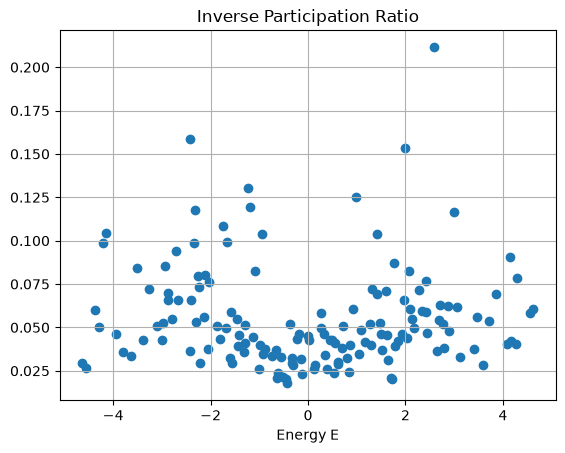

In [51]:
plt.scatter(eigenvalues, IPR)

plt.xlabel("Energy E")
# plt.ylabel(IPR)
plt.title("Inverse Participation Ratio")
plt.grid()
plt.show()